In [1]:
# 2-3-2026: 

import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

In [2]:
#random seed
np.random.seed(42)

In [3]:
print(f"Numpy version : {np.__version__}")

Numpy version : 1.24.3


In [81]:
# PART 1: FEATURE ENGINEERING
#Completed data pre-processing in the past independently. Bringing the datasets here:

import os

#new_working_directory = os.chdir(r"C:\Users\divya\OneDrive\Desktop\Canada_employment_2025\Courses\SFHA_ML")

os.getcwd()

import pathlib
print(pathlib.Path().absolute())

C:\Users\divya\OneDrive\Desktop\Canada_employment_2025\Courses\SFHA_ML


In [6]:
#Get laptop's RAM usage information first
import psutil
print(psutil.virtual_memory()) 

svmem(total=12674457600, available=7517057024, percent=40.7, used=5157400576, free=7517057024)


In [56]:
%%time

import gc

def create_scan_features(df):

        features = df.groupby("acquisitionNum", sort=False).agg(
        peak_count=("mz", "count"),
        mz_mean=("mz", "mean"),
        mz_std=("mz", "std"),
        intensity_mean=("intensity", "mean"),
        intensity_std=("intensity", "std"),
        intensity_max=("intensity", "max"),
        intensity_sum=("intensity", "sum"),
        precursor_mz=("precursorMZ", "first"),
        precursor_charge=("precursorCharge", "first"),
        retention_time=("retentionTime", "first"),
        collision_energy=("collisionEnergy", "first"),
        tot_ion_current=("totIonCurrent", "first")
    ).reset_index()

    return features

files = [
    ("no_BSA_1.csv", "no_BSA_1_features.csv"),
    ("no_BSA_2.csv", "no_BSA_2_features.csv"),
    ("five_BSA_1.csv", "five_BSA_1_features.csv"),
    ("five_BSA_2.csv", "five_BSA_2_features.csv"),
    ("fifty_BSA_1.csv", "fifty_BSA_1_features.csv"),
    ("fifty_BSA_2.csv", "fifty_BSA_2_features.csv")
]

for input_file, output_file in files:
    print(f"\nProcessing {input_file}...")

    df = pd.read_csv(
        input_file,
        dtype={
            "mz": "float32",
            "intensity": "float32",
            "acquisitionNum": "int32",
            "precursorMZ": "float32",
            "msLevel": "int8",
            "polarity": "int8",
            "collisionEnergy": "int8",
            "ionisationEnergy": "int8",
            "precursorCharge": "int8",
            "scanWindowLowerLimit": "float32",
            "scanWindowUpperLimit": "float32",
            "peaksCount": "int32",
            "precursorScanNum": "int32",
            "seqNum": "int32"
        }
    )

    df = df.drop(columns=[
        "filterString",
        "spectrumId",
        "mergedScan",
        "mergedResultScanNum",
        "mergedResultStartScanNum",
        "mergedResultEndScanNum",
        "ionMobilityDriftTime"
    ])

    features = create_scan_features(df)

    features.to_csv(output_file, index=False)

    del df
    del features
    gc.collect()


Processing no_BSA_1.csv...

Processing no_BSA_2.csv...

Processing five_BSA_1.csv...

Processing five_BSA_2.csv...

Processing fifty_BSA_1.csv...

Processing fifty_BSA_2.csv...
CPU times: total: 13min 6s
Wall time: 15min 4s


In [60]:
#Sanity check

print(features_no_bsa_1.shape)
print(features_no_bsa_1.info())

print(features_no_bsa_2.shape)
print(features_no_bsa_2.info())

print(features_five_bsa_1.shape)
print(features_five_bsa_1.info())

print(features_five_bsa_2.shape)
print(features_five_bsa_2.info())

print(features_fifty_bsa_1.shape)
print(features_fifty_bsa_1.info())

print(features_fifty_bsa_2.shape)
print(features_fifty_bsa_2.info())

(37761, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37761 entries, 0 to 37760
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acquisitionNum    37761 non-null  int64  
 1   peak_count        37761 non-null  int64  
 2   mz_mean           37761 non-null  float64
 3   mz_std            37761 non-null  float64
 4   intensity_mean    37761 non-null  float64
 5   intensity_std     37761 non-null  float64
 6   intensity_max     37761 non-null  float64
 7   intensity_sum     37761 non-null  float64
 8   precursor_mz      37761 non-null  float64
 9   precursor_charge  37761 non-null  int64  
 10  retention_time    37761 non-null  float64
 11  collision_energy  37761 non-null  int64  
 12  tot_ion_current   37761 non-null  float64
 13  BSA_condition     37761 non-null  int64  
dtypes: float64(9), int64(5)
memory usage: 4.0 MB
None
(38157, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38157 entr

In [61]:
#Stacking all files into a single dataframe:

features_no_bsa_1 = pd.read_csv("no_BSA_1_features.csv")
features_no_bsa_2 = pd.read_csv("no_BSA_2_features.csv")

features_five_bsa_1 = pd.read_csv("five_BSA_1_features.csv")
features_five_bsa_2 = pd.read_csv("five_BSA_2_features.csv")

features_fifty_bsa_1 = pd.read_csv("fifty_BSA_1_features.csv")
features_fifty_bsa_2 = pd.read_csv("fifty_BSA_2_features.csv")

#print(features_no_bsa_1.shape)

In [65]:
#Add column indicating experiment:
features_no_bsa_1["BSA_condition"] = 0
features_no_bsa_2["BSA_condition"] = 0
features_five_bsa_1["BSA_condition"] = 5
features_five_bsa_2["BSA_condition"] = 5
features_fifty_bsa_1["BSA_condition"] = 50
features_fifty_bsa_2["BSA_condition"] = 50

features_all = pd.concat([
    features_no_bsa_1,
    features_no_bsa_2,
    features_five_bsa_1,
    features_five_bsa_2,
    features_fifty_bsa_1,
    features_fifty_bsa_2
], ignore_index=True)

features_all["BSA_condition"] = features_all["BSA_condition"].astype("int8") #Changed column to int8 to save some memory.

print(features_all.shape)
print(features_all.info())
print(features_all["BSA_condition"].value_counts())

(213063, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213063 entries, 0 to 213062
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   acquisitionNum    213063 non-null  int64  
 1   peak_count        213063 non-null  int64  
 2   mz_mean           213063 non-null  float64
 3   mz_std            213063 non-null  float64
 4   intensity_mean    213063 non-null  float64
 5   intensity_std     213063 non-null  float64
 6   intensity_max     213063 non-null  float64
 7   intensity_sum     213063 non-null  float64
 8   precursor_mz      213063 non-null  float64
 9   precursor_charge  213063 non-null  int64  
 10  retention_time    213063 non-null  float64
 11  collision_energy  213063 non-null  int64  
 12  tot_ion_current   213063 non-null  float64
 13  BSA_condition     213063 non-null  int8   
dtypes: float64(9), int64(4), int8(1)
memory usage: 21.3 MB
None
BSA_condition
0     75918
5     68686
50   

In [66]:
features_all = features_all.drop(columns=["acquisitionNum"])

#ChatGPT says that since this is just MS scan ID#, it is not a real feature & can possible confuse the model.

In [67]:
features_all.isna().any().any()

False

In [68]:
## PART 2: ML MODEL TESTING 
#LDA CLASSIFICATION

#Define X features and y labels:

X = features_all.drop(columns=["BSA_condition"])
y = features_all["BSA_condition"]


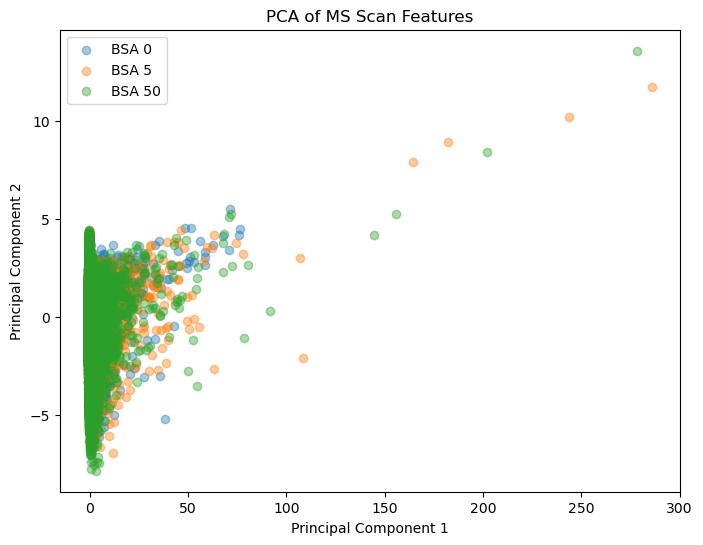

In [69]:
# But first, doing a PCA to see if the features correlate in any way at all:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  #This makes each feature with mean = 0, variance = 1.

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#Build a plotting dataframe:
pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "BSA_condition": y
})

plt.figure(figsize=(8,6))

for condition in [0,5,50]:
    subset = pca_df[pca_df["BSA_condition"] == condition]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"BSA {condition}",
        alpha=0.4
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.title("PCA of MS Scan Features")

plt.show()


In [70]:
# PCA did not show distinguishable variance - let's see what LDA classification gives:
# Train, test, split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)

In [71]:
# Scale features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
# Train LDA:

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

LinearDiscriminantAnalysis()

In [73]:
# Evaluate performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred_lda = lda.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lda))
print(confusion_matrix(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))

Accuracy: 0.42670077206486284
[[7377 4515 3292]
 [5284 6082 2371]
 [5035 3933 4724]]
              precision    recall  f1-score   support

           0       0.42      0.49      0.45     15184
           5       0.42      0.44      0.43     13737
          50       0.45      0.35      0.39     13692

    accuracy                           0.43     42613
   macro avg       0.43      0.42      0.42     42613
weighted avg       0.43      0.43      0.42     42613



In [74]:
%%time

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5656959143923216
[[9702 3193 2289]
 [3484 7907 2346]
 [3636 3559 6497]]
              precision    recall  f1-score   support

           0       0.58      0.64      0.61     15184
           5       0.54      0.58      0.56     13737
          50       0.58      0.47      0.52     13692

    accuracy                           0.57     42613
   macro avg       0.57      0.56      0.56     42613
weighted avg       0.57      0.57      0.56     42613

CPU times: total: 17min 18s
Wall time: 2min 36s


retention_time      0.154335
precursor_mz        0.114583
mz_mean             0.096316
intensity_max       0.094004
intensity_mean      0.092897
mz_std              0.091893
intensity_std       0.089476
peak_count          0.087187
tot_ion_current     0.079182
intensity_sum       0.079085
precursor_charge    0.021042
collision_energy    0.000000
dtype: float64


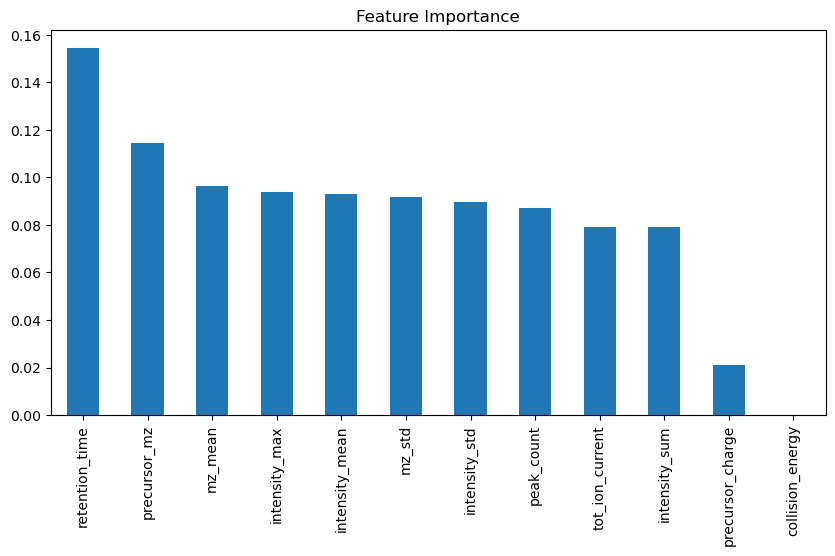

In [75]:
#The RF improved model accuracy from 36% to 57% and crossed 50%.
#The relationship between the engineered features and BSA condition is not well captured by linear decision boundaries.

#Which features mattered the most in the RF model?

importances = rf.feature_importances_

feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp)

feat_imp.plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance")
plt.show()

In [76]:
%%time

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": rf, 
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print("----", name, "----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("\n")

---- Logistic Regression ----
Accuracy: 0.3588341585901016
              precision    recall  f1-score   support

           0       0.51      0.00      0.01     15184
           5       0.35      0.54      0.43     13737
          50       0.36      0.57      0.45     13692

    accuracy                           0.36     42613
   macro avg       0.41      0.37      0.29     42613
weighted avg       0.41      0.36      0.28     42613



---- Random Forest ----
Accuracy: 0.5656959143923216
              precision    recall  f1-score   support

           0       0.58      0.64      0.61     15184
           5       0.54      0.58      0.56     13737
          50       0.58      0.47      0.52     13692

    accuracy                           0.57     42613
   macro avg       0.57      0.56      0.56     42613
weighted avg       0.57      0.57      0.56     42613



---- Gradient Boosting ----
Accuracy: 0.515945838124516
              precision    recall  f1-score   support

           

In [77]:
#Recall for class 0 in LR is 0 - bad - shows the relationship is non-linear. The relationship between spectral features and BSA condition is not linearly separable.

#RF recall scores considered reasonable for complex biological data which is considered noisy.

##Tree-based models substantially out-perform linear models.

import gc
gc.collect()

73

In [78]:
%%time

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200], #no. of trees in the forest
    "max_depth": [None, 10, 20], #how deep the trees can grow
    "min_samples_split": [2, 5], #minimum samples needed to split a node
    "min_samples_leaf": [1, 2] #minimum samples required at leaf nodes #changed from default settings because of RAM issues.
}  

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=6, #test 6 combinations for reasonable run-time (smaller search)
    cv=3,     # 3-fold cross-validation (model repeats training 3 times)
    n_jobs=1, #chose 1 instead of -1 because of RAM loss. The model runs sequentially instead of parallel to each other. 
    random_state=42
)

#Testing using 24 combinations instead of 108 to keep the search efficient.

search.fit(X_train, y_train) #This does 3x6 = 18 model trainings.

print(search.best_params_)


{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
CPU times: total: 11min 59s
Wall time: 19min 39s


In [53]:
#The hyperparameter results suggest the model does fine with 100 trees, complex decision boundaries, 1 leaf without overfitting. 

#17-3-2026
#Create final RF model with best parameters

best_rf = search.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))  #Results of this refined RF model show that the first RF model was near optimal.
                                              #The model is robust and not over-tuned. 


Accuracy: 0.5655785793067843
              precision    recall  f1-score   support

           0       0.57      0.65      0.61     15184
           5       0.53      0.60      0.56     13737
          50       0.60      0.44      0.51     13692

    accuracy                           0.57     42613
   macro avg       0.57      0.56      0.56     42613
weighted avg       0.57      0.57      0.56     42613



In [54]:
%%time

from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_rf, X, y, cv=3) #c=5 causes RAM exhaustion

print("Mean CV accuracy:", scores.mean())
print("Std:", scores.std())  

Mean CV accuracy: 0.44713535433181734
Std: 0.020317737351182707


In [55]:
#CV dropped! Huhu. # The lower cross-validation score (~0.45 vs ~0.57 test accuracy) suggests that the model may be overfitting, or 
#that performance varies across different data splits. 

#Trying CV only on training data:

scores_training = cross_val_score(best_rf, X_train, y_train, cv=3)

print("Mean CV accuracy:", scores_training.mean())
print("Std:", scores_training.std())   

# No difference when coverage is 100% or 80%.

Mean CV accuracy: 0.44713535433181734
Std: 0.020317737351182707


In [ ]:
#-- END --